<a href="https://colab.research.google.com/github/sabitaadh16/ResearchWork/blob/main/Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q torch torchvision pandas pillow scikit-learn matplotlib


In [ ]:
from pathlib import Path
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
import pandas as pd
from pathlib import Path
from PIL import Image

input_csv = (
    '/content/drive/MyDrive/DataSet/'
    'organized_images_labeled.csv'
)

df = pd.read_csv(input_csv)

print('Total image rows:', len(df))
print(df.head())
print(df.columns.tolist())


Total image rows: 8499
         image_name                                         image_path  \
0   5964_97_002.Jpg  /content/drive/MyDrive/DataSet/organized_image...   
1  1557_243_008.Jpg  /content/drive/MyDrive/DataSet/organized_image...   
2  5323_573_003.Jpg  /content/drive/MyDrive/DataSet/organized_image...   
3  3213_392_005.Jpg  /content/drive/MyDrive/DataSet/organized_image...   
4  1239_213_009.Jpg  /content/drive/MyDrive/DataSet/organized_image...   

   histo_label split  
0            0  test  
1            0  test  
2            0  test  
3            0  test  
4            0  test  
['image_name', 'image_path', 'histo_label', 'split']


In [ ]:
standardized_root = Path(
    '/content/drive/MyDrive/DataSet/'
    'ThyUS2Path_224x224'
)

standardized_root.mkdir(
    parents=True,
    exist_ok=True
)

print('New dataset folder:')
print(standardized_root)


New dataset folder:
/content/drive/MyDrive/DataSet/ThyUS2Path_224x224


In [ ]:
standardized_rows = []
failed_images = []

for index, row in df.iterrows():

    old_path = Path(row['image_path'])

    # Keep the same split and class folder structure
    new_folder = (
        standardized_root /
        str(row['split']) /
        ('class_' + str(int(row['histo_label'])))
    )

    new_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    # Use the original image filename
    new_path = new_folder / old_path.name

    try:
        with Image.open(old_path) as image:
            # Convert all images to RGB
            image = image.convert('RGB')

            # Make every saved image exactly 224 x 224
            image = image.resize((224, 224))

            # Save the corrected image
            image.save(new_path, format='JPEG')

        standardized_rows.append({
            'image_name': new_path.name,
            'image_path': str(new_path),
            'histo_label': int(row['histo_label']),
            'split': row['split']
        })

    except Exception as error:
        failed_images.append({
            'image_path': str(old_path),
            'error': str(error)
        })

standardized_df = pd.DataFrame(standardized_rows)

print('Images successfully standardized:', len(standardized_df))
print('Images that failed:', len(failed_images))


In [ ]:
wrong_size_images = []
missing_images = []

for image_path in standardized_df['image_path']:

    if not Path(image_path).exists():
        missing_images.append(image_path)
        continue

    with Image.open(image_path) as image:
        if image.size != (224, 224):
            wrong_size_images.append({
                'image_path': image_path,
                'size': image.size
            })

print('Missing standardized images:', len(missing_images))
print('Images with incorrect size:', len(wrong_size_images))


NameError: name 'standardized_df' is not defined

In [ ]:
print('Images by split:')
print(standardized_df['split'].value_counts())

print('\nImages by split and class:')
print(
    standardized_df
    .groupby(['split', 'histo_label'])
    .size()
)

Images by split:
split
train       5899
validate    1320
test        1280
Name: count, dtype: int64

Images by split and class:
split     histo_label
test      0               440
          1               840
train     0              2173
          1              3726
validate  0               484
          1               836
dtype: int64


In [ ]:
standardized_csv = (
    '/content/drive/MyDrive/DataSet/'
    'ThyUS2Path_224x224_main.csv'
)

standardized_df.to_csv(
    standardized_csv,
    index=False
)

print('Standardized main CSV saved at:')
print(standardized_csv)


Standardized main CSV saved at:
/content/drive/MyDrive/DataSet/ThyUS2Path_224x224_main.csv


In [ ]:
import pandas as pd

main_csv = (
    '/content/drive/MyDrive/DataSet/'
    'ThyUS2Path_224x224_main.csv'
)

main_df = pd.read_csv(main_csv)

train_df = main_df[
    main_df['split'] == 'train'
].copy()

validate_df = main_df[
    main_df['split'] == 'validate'
].copy()

test_df = main_df[
    main_df['split'] == 'test'
].copy()

print('Train images:', len(train_df))
print('Validation images:', len(validate_df))
print('Test images:', len(test_df))


Train images: 5899
Validation images: 1320
Test images: 1280


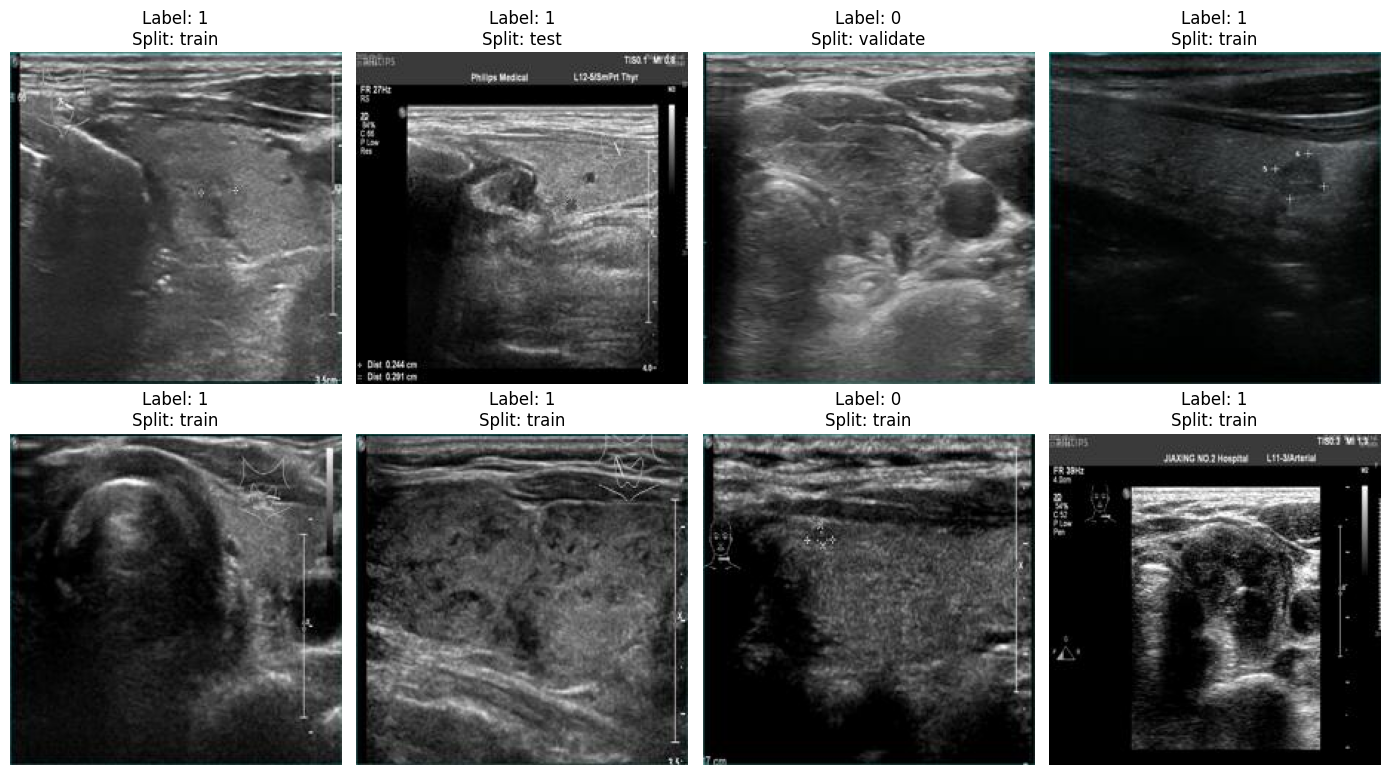

In [ ]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# Load the standardized CSV
csv_path = (
    '/content/drive/MyDrive/DataSet/'
    'ThyUS2Path_224x224_main.csv'
)

df = pd.read_csv(csv_path)

# Select eight random images
sample_images = df.sample(
    n=min(8, len(df)),
    random_state=42
)

plt.figure(figsize=(14, 8))

for i, (_, row) in enumerate(sample_images.iterrows()):

    image = Image.open(row['image_path']).convert('RGB')

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(
        'Label: ' + str(int(row['histo_label'])) +
        '\nSplit: ' + str(row['split'])
    )
    plt.axis('off')

plt.tight_layout()
plt.show()


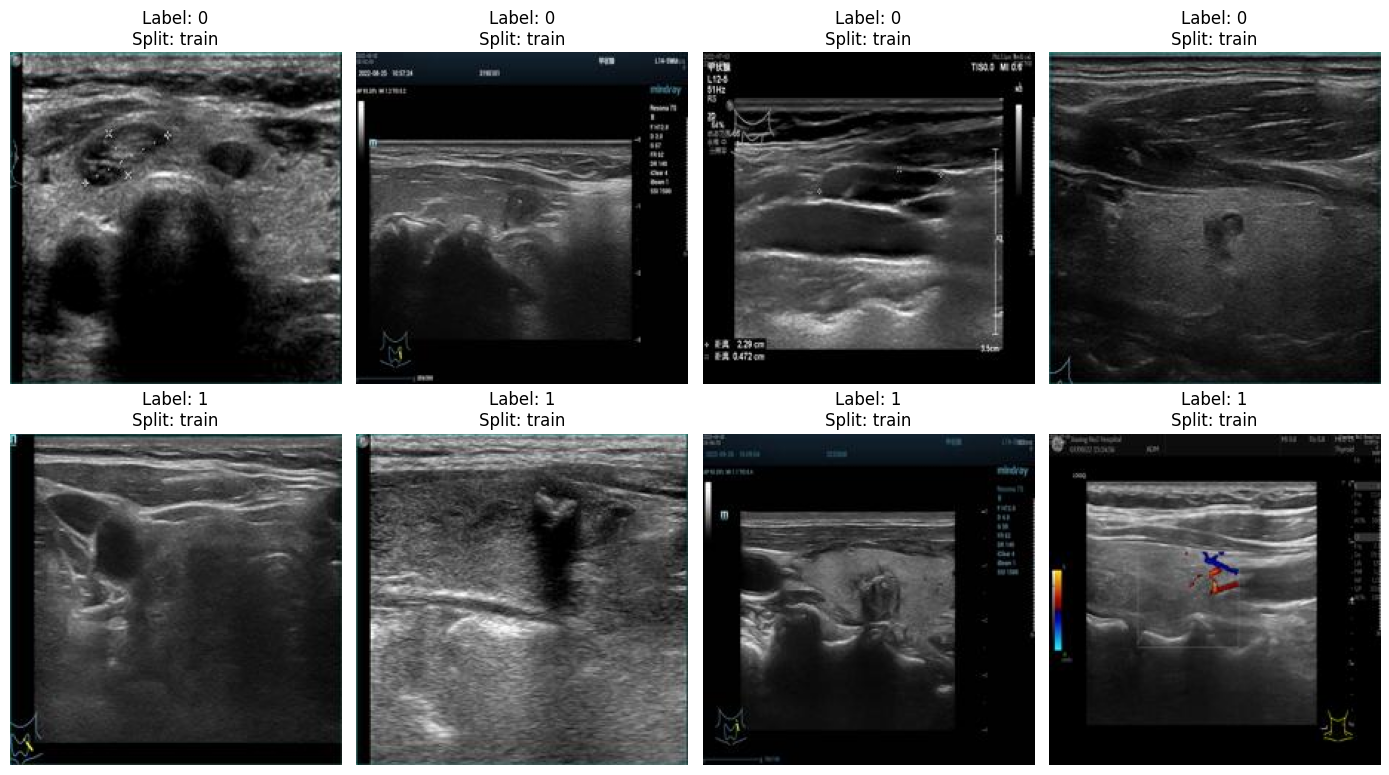

In [ ]:
# Select four class-0 and four class-1 images
class_0_images = df[
    df['histo_label'] == 0
].sample(n=4, random_state=42)

class_1_images = df[
    df['histo_label'] == 1
].sample(n=4, random_state=42)

selected_images = pd.concat([
    class_0_images,
    class_1_images
])

plt.figure(figsize=(14, 8))

for i, (_, row) in enumerate(selected_images.iterrows()):

    image = Image.open(row['image_path']).convert('RGB')

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(
        'Label: ' + str(int(row['histo_label'])) +
        '\nSplit: ' + str(row['split'])
    )
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from torchvision import transforms

# Small changes for training images only
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# No random changes for validation and test images
normal_transform = transforms.Compose([
    transforms.ToTensor()
])


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ThyroidDataset(Dataset):

    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['histo_label'])

        image = self.transform(image)

        return image, label


In [ ]:
train_df = main_df[
    main_df['split'] == 'train'
].copy()

validate_df = main_df[
    main_df['split'] == 'validate'
].copy()

test_df = main_df[
    main_df['split'] == 'test'
].copy()

print('Train images:', len(train_df))
print('Validation images:', len(validate_df))
print('Test images:', len(test_df))


NameError: name 'main_df' is not defined

In [ ]:
train_dataset = ThyroidDataset(
    train_df,
    train_transform
)

validate_dataset = ThyroidDataset(
    validate_df,
    normal_transform
)

test_dataset = ThyroidDataset(
    test_df,
    normal_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

validate_loader = DataLoader(
    validate_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print('DataLoaders created successfully.')


NameError: name 'ThyroidDataset' is not defined

In [ ]:
images, labels = next(iter(train_loader))

print('Image batch shape:', images.shape)
print('Label batch shape:', labels.shape)
print('Labels:', labels)


Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Labels: tensor([0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0])


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Use GPU if available
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('Using:', device)

# Load MobileNetV2
model = models.mobilenet_v2(weights='DEFAULT')

# Replace the final layer for class 0 and class 1
number_of_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(
    number_of_features,
    2
)

model = model.to(device)

print('MobileNetV2 is ready.')


Using: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 94.0MB/s]


MobileNetV2 is ready.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Use GPU if available
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('Using:', device)

# Load MobileNetV2
model = models.mobilenet_v2(weights='DEFAULT')

# Replace the final layer for class 0 and class 1
number_of_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(
    number_of_features,
    2
)

model = model.to(device)

print('MobileNetV2 is ready.')


Using: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 133MB/s]


MobileNetV2 is ready.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Select GPU if available
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

# Create the same MobileNetV2 structure used during training
model = models.mobilenet_v2(weights=None)

# Replace the final layer for two classes
number_of_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(number_of_features, 2)

# Location of the saved model
model_path = (
    '/content/drive/MyDrive/DataSet/'
    'best_mobilenetv2_model.pth'
)

# Load the saved model
checkpoint = torch.load(
    model_path,
    map_location=device
)

# Support either a full checkpoint or a state dictionary
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print('Saved model loaded successfully.')
print('Using device:', device)


Saved model loaded successfully.
Using device: cuda


In [ ]:
true_labels = []
predicted_labels = []
class_1_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        # Model predictions
        outputs = model(images)

        # Convert scores into probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Select the class with the highest score
        predictions = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.cpu().numpy())
        class_1_probabilities.extend(
            probabilities[:, 1].cpu().numpy()
        )

print('Number of test images evaluated:', len(true_labels))


NameError: name 'test_loader' is not defined